# Support Vector Machine Model

Faster SVM workflow aligned with the structure used in the other model notebooks.

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

## 1. Data Loading and Prep

In [2]:
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

data_path = project_root / "data" / "processed" / "model_ready_dataset.csv"
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at {data_path}. "
        "Make sure you run the notebook from the repo root or run the data prep pipeline first."
    )

df = pd.read_csv(data_path)
print(f"Loaded shape: {df.shape}")

df = df[df["Prospect_Outcome"].isin(["Won", "Churned"])].copy()
df["target"] = (df["Prospect_Outcome"] == "Churned").astype(int)
df.drop(columns=["Prospect_Outcome"], inplace=True)

leaky_cols = [
    "ren_membership_renewal_decision_mode", "ren_customer_response_mode",
    "Days_To_Close_Post_Renewal", "ren_has_churn_reason",
    "Total_Net_Paid", "net_paid_vs_last", "price_change_abs", "price_change_pct",
    "Payment_Method", "Proforma_Account_Stage", "Proforma_Membership_Status",
    "Proforma_Audit_Status", "Total_Renewal_Score_New", "Tenure_Scores",
    "Sustainability_Score", "Renewal_Score_At_Release", "em_membership_level_mode",
    "em_churn_risk_signals"
]
cols_before = set(df.columns)
df.drop(columns=leaky_cols, inplace=True, errors="ignore")
actually_dropped = cols_before - set(df.columns)
print(f"Dropped {len(actually_dropped)} leaky/non-predictive features: {sorted(actually_dropped)}")

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01)),
])

def make_preprocessor():
    transformers = []
    if num_cols:
        transformers.append(("num", numeric_pipe, num_cols))
    if cat_cols:
        transformers.append(("cat", categorical_pipe, cat_cols))
    return ColumnTransformer(transformers, remainder="drop")

print(f"\nFeatures: {X_train.shape[1]}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Churn rate: {y_train.mean():.2%}")

Loaded shape: (122082, 61)
Dropped 18 leaky/non-predictive features: ['Days_To_Close_Post_Renewal', 'Payment_Method', 'Proforma_Account_Stage', 'Proforma_Audit_Status', 'Proforma_Membership_Status', 'Renewal_Score_At_Release', 'Sustainability_Score', 'Tenure_Scores', 'Total_Net_Paid', 'Total_Renewal_Score_New', 'em_churn_risk_signals', 'em_membership_level_mode', 'net_paid_vs_last', 'price_change_abs', 'price_change_pct', 'ren_customer_response_mode', 'ren_has_churn_reason', 'ren_membership_renewal_decision_mode']

Features: 42
Train: 91115, Test: 22779
Churn rate: 11.12%


## 2. Baseline SVM

In [3]:
svm_pipe_base = Pipeline([
    ("preprocess", make_preprocessor()),
    ("clf", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=False,
    )),
])
svm_pipe_base.fit(X_train, y_train)

y_pred_base = svm_pipe_base.predict(X_test)
y_score_base = svm_pipe_base.decision_function(X_test)

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base),
    "Recall": recall_score(y_test, y_pred_base),
    "F1 Score": f1_score(y_test, y_pred_base),
    "ROC AUC": roc_auc_score(y_test, y_score_base),
}

print("=" * 60)
print("BASELINE SVM RESULTS")
print("=" * 60)
for k, v in baseline_metrics.items():
    print(f"{k:<10}: {v:.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=["Won", "Churned"]))

BASELINE SVM RESULTS
Accuracy  : 0.8411
Precision : 0.3986
Recall    : 0.8421
F1 Score  : 0.5411
ROC AUC   : 0.9195

              precision    recall  f1-score   support

         Won       0.98      0.84      0.90     20245
     Churned       0.40      0.84      0.54      2534

    accuracy                           0.84     22779
   macro avg       0.69      0.84      0.72     22779
weighted avg       0.91      0.84      0.86     22779



## 3. Hyperparameter Tuning

In [4]:
param_dist = {
    "clf__C": [0.5, 1.0, 2.0, 5.0],
    "clf__gamma": ["scale", 0.05, 0.1],
    "clf__kernel": ["linear", "rbf"],
}

svm_pipe = Pipeline([
    ("preprocess", make_preprocessor()),
    ("clf", SVC(class_weight="balanced", probability=False)),
])

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    svm_pipe,
    param_distributions=param_dist,
    n_iter=6,
    cv=cv_strat,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    random_state=42,
)
random_search.fit(X_train, y_train)

print(f"\nBest params: {random_search.best_params_}")
print(f"Best F1 (CV): {random_search.best_score_:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best params: {'clf__kernel': 'rbf', 'clf__gamma': 0.05, 'clf__C': 1.0}
Best F1 (CV): 0.5383


## 4. Final Evaluation

In [5]:
best_svm_pipe = random_search.best_estimator_

y_pred = best_svm_pipe.predict(X_test)
y_score = best_svm_pipe.decision_function(X_test)

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_score),
}

print("=" * 60)
print("TUNED SVM RESULTS")
print("=" * 60)
for k, v in tuned_metrics.items():
    print(f"{k:<10}: {v:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Won", "Churned"]))

TUNED SVM RESULTS
Accuracy  : 0.8508
Precision : 0.4132
Recall    : 0.8118
F1 Score  : 0.5477
ROC AUC   : 0.9157

              precision    recall  f1-score   support

         Won       0.97      0.86      0.91     20245
     Churned       0.41      0.81      0.55      2534

    accuracy                           0.85     22779
   macro avg       0.69      0.83      0.73     22779
weighted avg       0.91      0.85      0.87     22779



## 5. Diagnostics

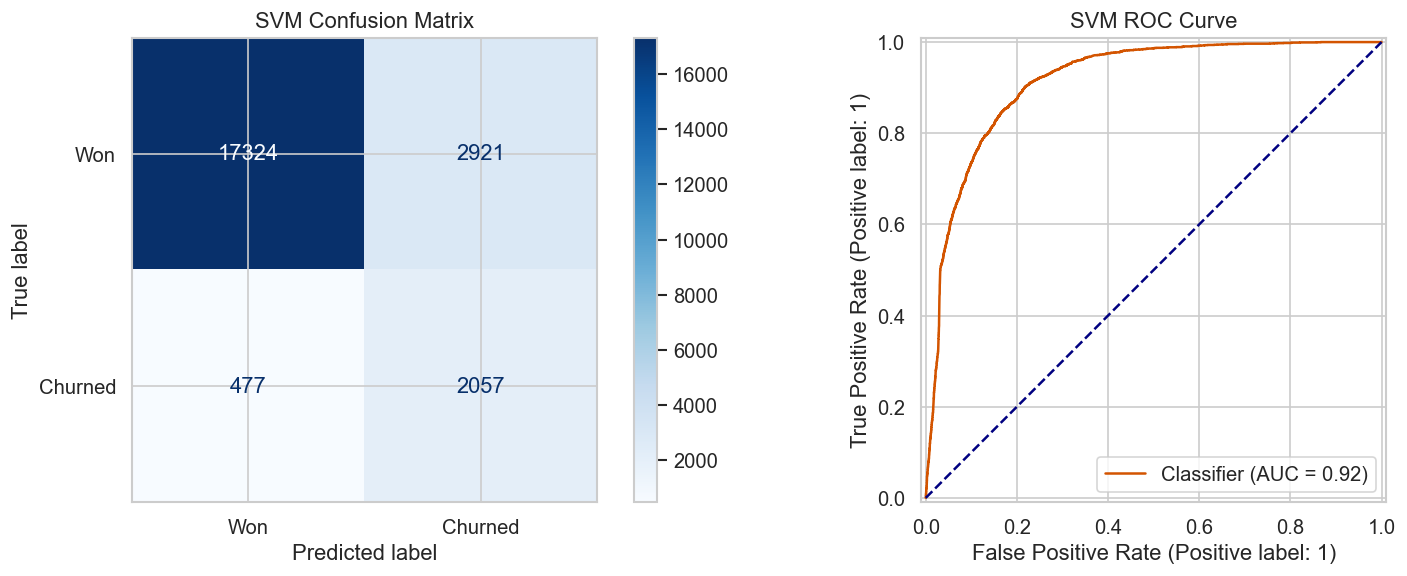

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Won", "Churned"],
    cmap="Blues",
    values_format="d",
    ax=axes[0],
)
axes[0].set_title("SVM Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_score, color="#d35400", ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="navy")
axes[1].set_title("SVM ROC Curve")

plt.tight_layout()
plt.show()